In [ ]:
%run "./02_EMS_preprocessing.ipynb"

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

FINAL_TABLES_DIR = TABLES_DIR / "final"
FINAL_FIGURES_DIR = FIGURES_DIR / "final"

FINAL_TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FINAL_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Tables finales :", FINAL_TABLES_DIR)
print("Figures finales :", FINAL_FIGURES_DIR)




ROOT_DIR  : C:\Users\Admin\Desktop\Projet_Artemis2
DATA_FILE : C:\Users\Admin\Desktop\Projet_Artemis2\data\Artemis.csv | existe: True
RANDOM_SEED: 42 | DEVICE: cpu
CONFIGURATION DU PROJET HESS

BATTERIE ÉNERGIE
Énergie          : 13709.89 Wh
Tension          : 450.00 V
Capacité         : 30.4664 Ah
Masse            : 55.12 kg
Courant recharge : -14.00 A
Courant décharge : 28.00 A
Configuration    : 125S7P

BATTERIE PUISSANCE
Énergie          : 2987.12 Wh
Tension          : 402.60 V
Capacité         : 7.4196 Ah
Masse            : 50.02 kg
Courant recharge : -130.00 A
Courant décharge : 400.00 A
Configuration    : 122S2P

HESS
Énergie totale   : 16697.01 Wh
Masse totale     : 105.14 kg
Tension du bus   : 402.60 V
Puissance min    : -58638.00 W
Puissance max    : 173640.00 W

MODÈLES
LSTM seul        : 7 → 64 → 3
LSTM NS          : 15 → 64 → 3
GNN simple       : 12 → 32 → 1
MLP simple       : 5 → 64 → 32 → 1
MLP NS           : 17 → 64 → 32 → 1

Device           : cpu
Fichier          : C:

In [39]:
# Cellule 2 — Fonctions de chargement


def load_required_csv(filename):
    path = TABLES_DIR / filename

    if not path.exists():
        available = sorted(
            p.name
            for p in TABLES_DIR.glob("*.csv")
        )

        raise FileNotFoundError(
            f"Fichier obligatoire absent : {path}\n"
            f"CSV disponibles : {available}"
        )

    data = pd.read_csv(path)

    print(
        f"{filename:<45}",
        data.shape,
    )

    return data


def load_optional_csv(candidates):
    for filename in candidates:
        path = TABLES_DIR / filename

        if path.exists():
            data = pd.read_csv(path)

            print(
                f"{filename:<45}",
                data.shape,
            )

            return data, path

    print(
        "Fichier optionnel absent :",
        candidates,
    )

    return None, None


def require_columns(
    data,
    columns,
    table_name,
):
    missing = sorted(
        set(columns)
        - set(data.columns)
    )

    if missing:
        raise ValueError(
            f"{table_name} : colonnes absentes "
            f"{missing}"
        )

In [40]:
# Cellule 3 — Chargement des résultats existants

ablation_regression = load_required_csv(
    "ablation_regression_summary.csv"
)

ablation_regression_detail = load_required_csv(
    "ablation_regression_detail.csv"
)

ablation_physical = load_required_csv(
    "ablation_physical_summary.csv"
)

ablation_physical_detail = load_required_csv(
    "ablation_physical_detail.csv"
)

ablation_contributions = load_required_csv(
    "ablation_component_contributions.csv"
)

simulation_summary = load_required_csv(
    "simulation_complete_comparison.csv"
)

robustness_lstm = load_required_csv(
    "robustesse_bruit_lstm.csv"
)

robustness_symbolic = load_required_csv(
    "robustesse_bruit_symbolique.csv"
)

robustness_sensor, robustness_sensor_path = (
    load_optional_csv([
        "robustesse_bruit_capteurs.csv",
        "robustesse_capteurs.csv",
    ])
)

robustness_dynamic, robustness_dynamic_path = (
    load_optional_csv([
        "robustesse_dynamique_neurosymbolique.csv",
        "robustesse_dynamique_complete.csv",
        "robustesse_dynamique_historique.csv",
    ])
)

global_comparison, global_comparison_path = (
    load_optional_csv([
        "evaluation_comparative_finale.csv",
        "evaluation_comparative_strategies.csv",
        "comparaison_globale_strategies.csv",
        "strategy_comparison_final.csv",
    ])
)

ablation_regression_summary.csv               (15, 10)
ablation_regression_detail.csv                (45, 9)
ablation_physical_summary.csv                 (13, 9)
ablation_physical_detail.csv                  (39, 10)
ablation_component_contributions.csv          (5, 6)
simulation_complete_comparison.csv            (4, 11)
robustesse_bruit_lstm.csv                     (6, 7)
robustesse_bruit_symbolique.csv               (6, 7)
robustesse_bruit_capteurs.csv                 (15, 7)
robustesse_dynamique_historique.csv           (3, 6)
Fichier optionnel absent : ['evaluation_comparative_finale.csv', 'evaluation_comparative_strategies.csv', 'comparaison_globale_strategies.csv', 'strategy_comparison_final.csv']


In [41]:
# Cellule 4 — Vérification des colonnes principales


require_columns(
    ablation_regression,
    [
        "strategy",
        "split",
        "mae_mean",
        "mae_std",
        "rmse_mean",
        "rmse_std",
        "r2_mean",
        "r2_std",
        "parameters",
    ],
    "ablation_regression",
)

require_columns(
    ablation_physical,
    [
        "strategy",
        "split",
        "feasibility_mean",
        "cost_mean",
        "cost_std",
        "regret_mean",
        "regret_std",
        "common_samples",
    ],
    "ablation_physical",
)

require_columns(
    ablation_physical_detail,
    [
        "strategy",
        "split",
        "seed",
        "mean_cost_common",
        "mean_regret_common",
        "feasibility_percent",
        "common_feasible_samples",
    ],
    "ablation_physical_detail",
)

require_columns(
    robustness_lstm,
    [
        "k",
        "variant",
        "mae_mean",
        "cost_mean",
        "feasibility_mean",
    ],
    "robustness_lstm",
)

require_columns(
    robustness_symbolic,
    [
        "flip_rate",
        "variant",
        "mae_mean",
        "cost_mean",
        "feasibility_mean",
    ],
    "robustness_symbolic",
)

print("Vérification des colonnes : OK")

Vérification des colonnes : OK


In [42]:
# Cellule 5 — Contrôle du masque commun de coût


mask_control = (
    ablation_physical_detail
    .groupby(
        [
            "split",
            "seed",
        ],
        as_index=False,
    )
    .agg(
        min_common_samples=(
            "common_feasible_samples",
            "min",
        ),
        max_common_samples=(
            "common_feasible_samples",
            "max",
        ),
    )
)

mask_control[
    "same_mask_size"
] = (
    mask_control[
        "min_common_samples"
    ]
    == mask_control[
        "max_common_samples"
    ]
)

display(mask_control)

if not mask_control[
    "same_mask_size"
].all():
    print(
        "ATTENTION : le nombre de cas communs "
        "diffère pour certaines évaluations."
    )

    print(
        "Pour le rapport final, utiliser de préférence "
        "la version recalculée avec un masque commun fixe."
    )
else:
    print(
        "Nombre de cas communs cohérent "
        "pour chaque split et chaque graine."
    )


,split,seed,min_common_samples,max_common_samples,same_mask_size
0,test,42,2605,2605,True
1,test,43,2620,2620,True
2,test,44,2538,2538,True
3,validation,42,3096,3096,True
4,validation,43,3096,3096,True
5,validation,44,3086,3086,True


Nombre de cas communs cohérent pour chaque split et chaque graine.


In [43]:
# Cellule 6 — Tableau final des performances de régression


regression_test = (
    ablation_regression[
        ablation_regression[
            "split"
        ].eq("test")
    ]
    .copy()
    .sort_values(
        [
            "mae_mean",
            "rmse_mean",
        ]
    )
    .reset_index(drop=True)
)

regression_test[
    "rank_mae"
] = np.arange(
    1,
    len(regression_test) + 1,
)

regression_final = regression_test[
    [
        "rank_mae",
        "strategy",
        "mae_mean",
        "mae_std",
        "rmse_mean",
        "rmse_std",
        "r2_mean",
        "r2_std",
        "parameters",
        "inference_ms_mean",
    ]
].copy()

display(regression_final)

regression_final.to_csv(
    FINAL_TABLES_DIR
    / "tableau_final_regression.csv",
    index=False,
)

,rank_mae,strategy,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,parameters,inference_ms_mean
0,1,MLP_symbolique,0.110716,0.003248,0.191785,0.008202,0.589986,0.035394,2753,0.001040
1,2,MLP_LSTM,0.115040,0.007822,0.196683,0.017173,0.567110,0.074958,2689,0.000462
2,3,MLP,0.121275,0.003277,0.202355,0.006934,0.543744,0.031532,2497,0.000593
3,4,MLP_neurosymbolique,0.126436,0.007261,0.198440,0.013367,0.560244,0.057934,3009,0.000513
4,5,MLP_fuzzy,0.144997,0.002092,0.218187,0.008251,0.469467,0.039862,2561,0.000732


In [44]:
# Cellule 7 — Tableau final des performances physiques


physical_validation = (
    ablation_physical[
        ablation_physical[
            "split"
        ].eq("validation")
    ]
    .copy()
    .sort_values(
        [
            "cost_mean",
            "regret_mean",
        ]
    )
    .reset_index(drop=True)
)

physical_test = (
    ablation_physical[
        ablation_physical[
            "split"
        ].eq("test")
    ]
    .copy()
    .sort_values(
        [
            "cost_mean",
            "regret_mean",
        ]
    )
    .reset_index(drop=True)
)

physical_validation[
    "rank_validation"
] = np.arange(
    1,
    len(physical_validation) + 1,
)

physical_test[
    "rank_test"
] = np.arange(
    1,
    len(physical_test) + 1,
)

display(
    physical_validation[
        [
            "rank_validation",
            "strategy",
            "feasibility_mean",
            "cost_mean",
            "cost_std",
            "regret_mean",
            "regret_std",
            "common_samples",
        ]
    ]
)

display(
    physical_test[
        [
            "rank_test",
            "strategy",
            "feasibility_mean",
            "cost_mean",
            "cost_std",
            "regret_mean",
            "regret_std",
            "common_samples",
        ]
    ]
)

physical_validation.to_csv(
    FINAL_TABLES_DIR
    / "tableau_final_physique_validation.csv",
    index=False,
)

physical_test.to_csv(
    FINAL_TABLES_DIR
    / "tableau_final_physique_test.csv",
    index=False,
)

,rank_validation,strategy,feasibility_mean,cost_mean,cost_std,regret_mean,regret_std,common_samples
0,1,Alpha-star,100.000000,0.210987,0.000221,0.000000,0.000000,3086
1,2,MLP_LSTM,100.000000,0.212223,0.000168,0.001236,0.000099,3086
2,3,MLP_symbolique,100.000000,0.212347,0.000112,0.001360,0.000144,3086
3,4,MLP,100.000000,0.212611,0.000468,0.001624,0.000260,3086
4,5,MLP_neurosymbolique,100.000000,0.212998,0.000267,0.002010,0.000365,3086
5,6,MLP_fuzzy,99.892334,0.213921,0.000393,0.002934,0.000442,3086


,rank_test,strategy,feasibility_mean,cost_mean,cost_std,regret_mean,regret_std,common_samples
0,1,Alpha-star,100.000000,0.215887,0.001608,0.000000,0.000000,2538
1,2,MLP_symbolique,85.816993,0.217178,0.001572,0.001291,0.000490,2538
2,3,MLP_LSTM,85.827887,0.217527,0.001703,0.001640,0.000391,2538
3,4,MLP,85.871460,0.218187,0.001900,0.002300,0.000443,2538
4,5,MLP_neurosymbolique,85.947712,0.218781,0.001480,0.002894,0.000378,2538
5,6,MLP_fuzzy,84.716776,0.221189,0.001357,0.005302,0.000397,2538
6,7,MLP_neurosymbolique_residuel,85.882353,0.231298,0.001299,0.015411,0.000308,2538


In [45]:
# Cellule 8 — Sélection stricte et choix opérationnel


ABLATION_MODEL_NAMES = [
    "MLP",
    "MLP_symbolique",
    "MLP_LSTM",
    "MLP_fuzzy",
    "MLP_neurosymbolique",
]

validation_candidates = (
    physical_validation[
        physical_validation[
            "strategy"
        ].isin(
            ABLATION_MODEL_NAMES
        )
    ]
    .copy()
)

strict_validation_winner = str(
    validation_candidates.iloc[0][
        "strategy"
    ]
)

strict_validation_cost = float(
    validation_candidates.iloc[0][
        "cost_mean"
    ]
)

OPERATIONAL_NEUROSYMBOLIC_MODEL = (
    "MLP_symbolique"
)

if (
    OPERATIONAL_NEUROSYMBOLIC_MODEL
    not in ABLATION_MODEL_NAMES
):
    raise ValueError(
        "Architecture opérationnelle inconnue."
    )

operational_validation_row = (
    validation_candidates[
        validation_candidates[
            "strategy"
        ].eq(
            OPERATIONAL_NEUROSYMBOLIC_MODEL
        )
    ]
    .iloc[0]
)

operational_test_row = (
    physical_test[
        physical_test[
            "strategy"
        ].eq(
            OPERATIONAL_NEUROSYMBOLIC_MODEL
        )
    ]
    .iloc[0]
)

strict_test_row = (
    physical_test[
        physical_test[
            "strategy"
        ].eq(
            strict_validation_winner
        )
    ]
    .iloc[0]
)

decision_table = pd.DataFrame([
    {
        "role": (
            "Gagnant selon le coût "
            "strict de validation"
        ),
        "model": strict_validation_winner,
        "validation_cost": strict_validation_cost,
        "test_cost": float(
            strict_test_row[
                "cost_mean"
            ]
        ),
        "test_feasibility_percent": float(
            strict_test_row[
                "feasibility_mean"
            ]
        ),
    },
    {
        "role": (
            "Architecture neurosymbolique "
            "opérationnelle"
        ),
        "model": (
            OPERATIONAL_NEUROSYMBOLIC_MODEL
        ),
        "validation_cost": float(
            operational_validation_row[
                "cost_mean"
            ]
        ),
        "test_cost": float(
            operational_test_row[
                "cost_mean"
            ]
        ),
        "test_feasibility_percent": float(
            operational_test_row[
                "feasibility_mean"
            ]
        ),
    },
])

display(decision_table)

decision_table.to_csv(
    FINAL_TABLES_DIR
    / "selection_architecture_finale.csv",
    index=False,
)

,role,model,validation_cost,test_cost,test_feasibility_percent
0,Gagnant selon le coût strict de validation,MLP_LSTM,0.212223,0.217527,85.827887
1,Architecture neurosymbolique opérationnelle,MLP_symbolique,0.212347,0.217178,85.816993


In [50]:
# Cellule 9 — Sélection de la graine du modèle opérationnel


operational_seed_ranking = (
    ablation_physical_detail[
        ablation_physical_detail[
            "split"
        ].eq("validation")
        & ablation_physical_detail[
            "strategy"
        ].eq(
            OPERATIONAL_NEUROSYMBOLIC_MODEL
        )
    ]
    .sort_values(
        [
            "mean_cost_common",
            "mean_regret_common",
        ]
    )
    .reset_index(drop=True)
)

if operational_seed_ranking.empty:
    raise ValueError(
        "Aucun résultat de validation pour "
        "le modèle opérationnel."
    )

operational_seed = int(
    operational_seed_ranking.iloc[0][
        "seed"
    ]
)

operational_checkpoint = (
    MODELS_DIR
    / (
        "ablation_"
        f"{OPERATIONAL_NEUROSYMBOLIC_MODEL}"
        f"_seed_{operational_seed}.pt"
    )
)

operational_scaler = (
    MODELS_DIR
    / (
        "ablation_"
        f"{OPERATIONAL_NEUROSYMBOLIC_MODEL}"
        "_scaler.npz"
    )
)

print(
    "Modèle opérationnel :",
    OPERATIONAL_NEUROSYMBOLIC_MODEL,
)

print(
    "Graine sélectionnée sur validation :",
    operational_seed,
)

print(
    "Checkpoint :",
    operational_checkpoint,
)

print(
    "Normalisation :",
    operational_scaler,
)

if not operational_checkpoint.exists():
    print(
        "ATTENTION : checkpoint non trouvé :",
        operational_checkpoint,
    )

if not operational_scaler.exists():
    print(
        "ATTENTION : scaler non trouvé :",
        operational_scaler,
    )

Modèle opérationnel : MLP_symbolique
Graine sélectionnée sur validation : 44
Checkpoint : C:\Users\Admin\Desktop\Projet_Artemis2\models\ablation_MLP_symbolique_seed_44.pt
Normalisation : C:\Users\Admin\Desktop\Projet_Artemis2\models\ablation_MLP_symbolique_scaler.npz


In [51]:
# Cellule 10 — Contribution des composants


contribution_final = (
    ablation_contributions
    .copy()
    .sort_values(
        [
            "test_cost",
            "test_mae",
        ]
    )
    .reset_index(drop=True)
)

baseline_mae = float(
    contribution_final.loc[
        contribution_final[
            "strategy"
        ].eq("MLP"),
        "test_mae",
    ].iloc[0]
)

baseline_cost = float(
    contribution_final.loc[
        contribution_final[
            "strategy"
        ].eq("MLP"),
        "test_cost",
    ].iloc[0]
)

contribution_final[
    "mae_improvement_vs_baseline_percent"
] = (
    -100.0
    * contribution_final[
        "delta_mae_vs_baseline"
    ]
    / baseline_mae
)

contribution_final[
    "cost_improvement_vs_baseline_percent"
] = (
    -100.0
    * contribution_final[
        "delta_cost_vs_baseline"
    ]
    / baseline_cost
)

display(contribution_final)

contribution_final.to_csv(
    FINAL_TABLES_DIR
    / "tableau_final_contribution_composants.csv",
    index=False,
)

,strategy,test_mae,delta_mae_vs_baseline,test_cost,delta_cost_vs_baseline,test_feasibility_percent,mae_improvement_vs_baseline_percent,cost_improvement_vs_baseline_percent
0,MLP_symbolique,0.110716,-0.010559,0.217178,-0.001008,85.816993,8.706451,0.462080
1,MLP_LSTM,0.115040,-0.006235,0.217527,-0.000659,85.827887,5.141249,0.302082
2,MLP,0.121275,0.000000,0.218187,0.000000,85.871460,-0.000000,-0.000000
3,MLP_neurosymbolique,0.126436,0.005162,0.218781,0.000595,85.947712,-4.256090,-0.272496
4,MLP_fuzzy,0.144997,0.023722,0.221189,0.003002,84.716776,-19.560475,-1.375951


In [52]:
# Cellule 11 — Références propres pour l’analyse de robustesse


clean_regression_lookup = (
    ablation_regression[
        ablation_regression[
            "split"
        ].eq("test")
    ]
    .set_index("strategy")[
        "mae_mean"
    ]
    .to_dict()
)

clean_cost_lookup = (
    ablation_physical[
        ablation_physical[
            "split"
        ].eq("test")
    ]
    .set_index("strategy")[
        "cost_mean"
    ]
    .to_dict()
)

print(
    "Références propres disponibles :",
    sorted(clean_regression_lookup),
)

Références propres disponibles : ['MLP', 'MLP_LSTM', 'MLP_fuzzy', 'MLP_neurosymbolique', 'MLP_symbolique']


In [53]:
# Cellule 12 — Consolidation de la robustesse LSTM


robustness_lstm_final = (
    robustness_lstm.copy()
)

robustness_lstm_final[
    "clean_mae"
] = robustness_lstm_final[
    "variant"
].map(
    clean_regression_lookup
)

robustness_lstm_final[
    "clean_cost"
] = robustness_lstm_final[
    "variant"
].map(
    clean_cost_lookup
)

robustness_lstm_final[
    "delta_mae"
] = (
    robustness_lstm_final[
        "mae_mean"
    ]
    - robustness_lstm_final[
        "clean_mae"
    ]
)

robustness_lstm_final[
    "delta_cost"
] = (
    robustness_lstm_final[
        "cost_mean"
    ]
    - robustness_lstm_final[
        "clean_cost"
    ]
)

robustness_lstm_final[
    "mae_degradation_percent"
] = (
    100.0
    * robustness_lstm_final[
        "delta_mae"
    ]
    / robustness_lstm_final[
        "clean_mae"
    ]
)

display(
    robustness_lstm_final.sort_values(
        [
            "variant",
            "k",
        ]
    )
)

robustness_lstm_final.to_csv(
    FINAL_TABLES_DIR
    / "tableau_final_robustesse_lstm.csv",
    index=False,
)

,k,variant,mae_mean,mae_std,cost_mean,cost_std,feasibility_mean,clean_mae,clean_cost,delta_mae,delta_cost,mae_degradation_percent
0,0.5,MLP_LSTM,0.109067,0.000230,0.218644,0.000034,85.801307,0.115040,0.217527,-0.005972,0.001116,-5.191463
2,1.0,MLP_LSTM,0.112720,0.000584,0.219254,0.000100,85.801307,0.115040,0.217527,-0.002320,0.001726,-2.016604
4,2.0,MLP_LSTM,0.122796,0.000868,0.221032,0.000156,85.657516,0.115040,0.217527,0.007756,0.003504,6.742439
1,0.5,MLP_neurosymbolique,0.119160,0.000344,0.219460,0.000035,85.943791,0.126436,0.218781,-0.007277,0.000679,-5.755307
3,1.0,MLP_neurosymbolique,0.121693,0.000526,0.219792,0.000119,85.861438,0.126436,0.218781,-0.004743,0.001011,-3.751253
5,2.0,MLP_neurosymbolique,0.128576,0.000826,0.220174,0.000191,85.274510,0.126436,0.218781,0.002140,0.001393,1.692504


In [54]:


# Cellule 13 — Consolidation de la robustesse symbolique


robustness_symbolic_final = (
    robustness_symbolic.copy()
)

robustness_symbolic_final[
    "clean_mae"
] = robustness_symbolic_final[
    "variant"
].map(
    clean_regression_lookup
)

robustness_symbolic_final[
    "clean_cost"
] = robustness_symbolic_final[
    "variant"
].map(
    clean_cost_lookup
)

robustness_symbolic_final[
    "delta_mae"
] = (
    robustness_symbolic_final[
        "mae_mean"
    ]
    - robustness_symbolic_final[
        "clean_mae"
    ]
)

robustness_symbolic_final[
    "delta_cost"
] = (
    robustness_symbolic_final[
        "cost_mean"
    ]
    - robustness_symbolic_final[
        "clean_cost"
    ]
)

robustness_symbolic_final[
    "mae_degradation_percent"
] = (
    100.0
    * robustness_symbolic_final[
        "delta_mae"
    ]
    / robustness_symbolic_final[
        "clean_mae"
    ]
)

display(
    robustness_symbolic_final.sort_values(
        [
            "variant",
            "flip_rate",
        ]
    )
)

robustness_symbolic_final.to_csv(
    FINAL_TABLES_DIR
    / "tableau_final_robustesse_symbolique.csv",
    index=False,
)




,flip_rate,variant,mae_mean,mae_std,cost_mean,cost_std,feasibility_mean,clean_mae,clean_cost,delta_mae,delta_cost,mae_degradation_percent
0,0.01,MLP_neurosymbolique,0.127027,0.006145,0.219747,0.000270,85.943791,0.126436,0.218781,0.000590,0.000965,0.466782
2,0.05,MLP_neurosymbolique,0.131025,0.005954,0.220368,0.000262,85.939869,0.126436,0.218781,0.004588,0.001587,3.628874
4,0.10,MLP_neurosymbolique,0.135688,0.005406,0.221065,0.000324,85.905882,0.126436,0.218781,0.009252,0.002284,7.317401
1,0.01,MLP_symbolique,0.111866,0.002703,0.218472,0.000408,85.822222,0.110716,0.217178,0.001150,0.001294,1.039010
3,0.05,MLP_symbolique,0.116910,0.002597,0.219131,0.000392,85.803922,0.110716,0.217178,0.006194,0.001953,5.594711
5,0.10,MLP_symbolique,0.122978,0.002840,0.219949,0.000425,85.802614,0.110716,0.217178,0.012262,0.002771,11.075528


In [55]:
# Cellule 14 — Simulation dynamique finale

simulation_final = (
    simulation_summary.copy()
)

display(simulation_final)

simulation_final.to_csv(
    FINAL_TABLES_DIR
    / "tableau_final_simulation_dynamique.csv",
    index=False,
)

print(
    "Colonnes disponibles :",
    simulation_final.columns.tolist(),
)

,strategie,SOC_EB_meme_instant,SOC_PB_meme_instant,SOC_EB_min,SOC_EB_max,I_EB_rms,I_EB_max,corrections,corrections_pct,curtailed_energy_Wh,unserved_energy_Wh
0,historique,0.201184,0.208319,0.200214,0.364989,13.770824,27.999794,381,10.487201,0.0,0.000000e+00
1,logique_floue,0.217353,0.219045,0.216860,0.364989,9.740573,28.000000,269,7.404349,0.0,2.021099e-15
2,mlp_simple,0.214265,0.219572,0.213655,0.364989,10.935607,28.000000,207,5.697770,0.0,2.021099e-15
3,neurosymbolique_complet,0.219339,0.217898,0.218831,0.364989,9.662977,28.000000,247,6.798789,0.0,2.021099e-15


Colonnes disponibles : ['strategie', 'SOC_EB_meme_instant', 'SOC_PB_meme_instant', 'SOC_EB_min', 'SOC_EB_max', 'I_EB_rms', 'I_EB_max', 'corrections', 'corrections_pct', 'curtailed_energy_Wh', 'unserved_energy_Wh']


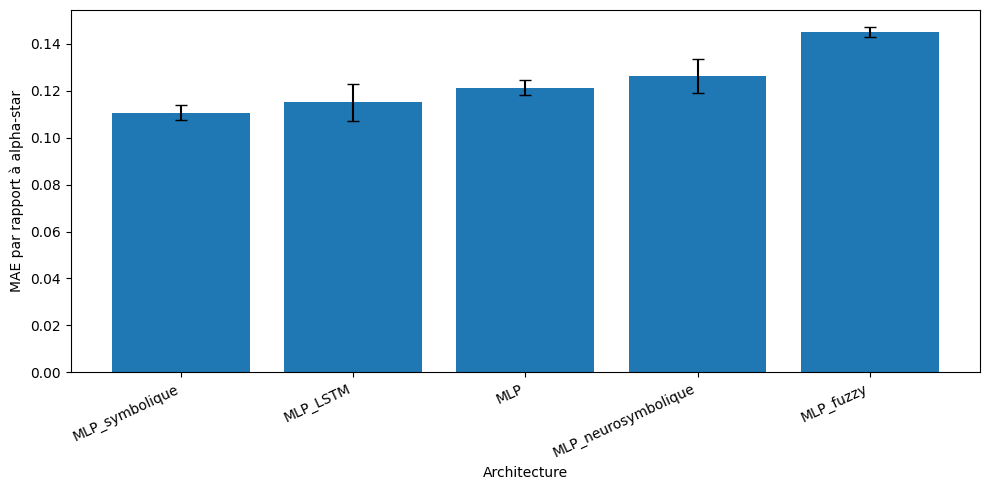

In [56]:

# Cellule 15 — Figure finale : précision de l’ablation


plot_regression = (
    regression_test
    .sort_values(
        "mae_mean"
    )
)

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    plot_regression[
        "strategy"
    ],
    plot_regression[
        "mae_mean"
    ],
    yerr=plot_regression[
        "mae_std"
    ].fillna(0.0),
    capsize=4,
)

plt.ylabel(
    "MAE par rapport à alpha-star"
)

plt.xlabel(
    "Architecture"
)

plt.xticks(
    rotation=25,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FINAL_FIGURES_DIR
    / "figure_finale_ablation_mae.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


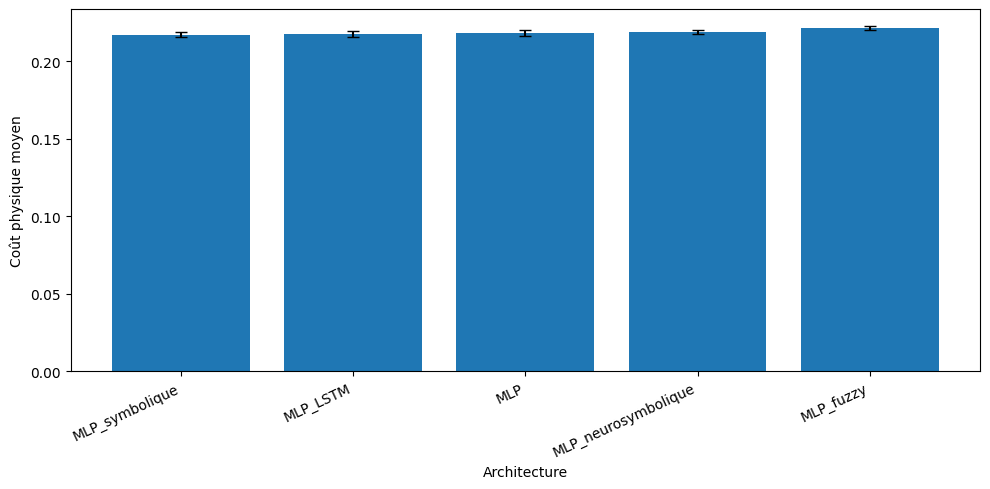

In [57]:

# Cellule 16 — Figure finale : coût physique


plot_physical = (
    physical_test[
        physical_test[
            "strategy"
        ].isin(
            ABLATION_MODEL_NAMES
        )
    ]
    .sort_values(
        "cost_mean"
    )
)

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    plot_physical[
        "strategy"
    ],
    plot_physical[
        "cost_mean"
    ],
    yerr=plot_physical[
        "cost_std"
    ].fillna(0.0),
    capsize=4,
)

plt.ylabel(
    "Coût physique moyen"
)

plt.xlabel(
    "Architecture"
)

plt.xticks(
    rotation=25,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FINAL_FIGURES_DIR
    / "figure_finale_cout_physique.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

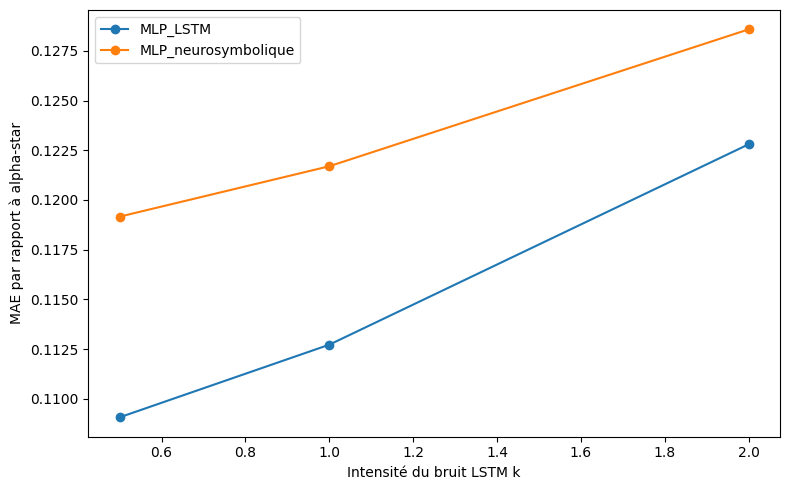

In [58]:


# Cellule 17 — Figure finale : robustesse aux erreurs LSTM


plt.figure(
    figsize=(8, 5)
)

for variant_name in sorted(
    robustness_lstm_final[
        "variant"
    ].unique()
):
    subset = (
        robustness_lstm_final[
            robustness_lstm_final[
                "variant"
            ].eq(variant_name)
        ]
        .sort_values("k")
    )

    plt.plot(
        subset["k"],
        subset["mae_mean"],
        marker="o",
        label=variant_name,
    )

plt.xlabel(
    "Intensité du bruit LSTM k"
)

plt.ylabel(
    "MAE par rapport à alpha-star"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FINAL_FIGURES_DIR
    / "figure_finale_robustesse_lstm.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()




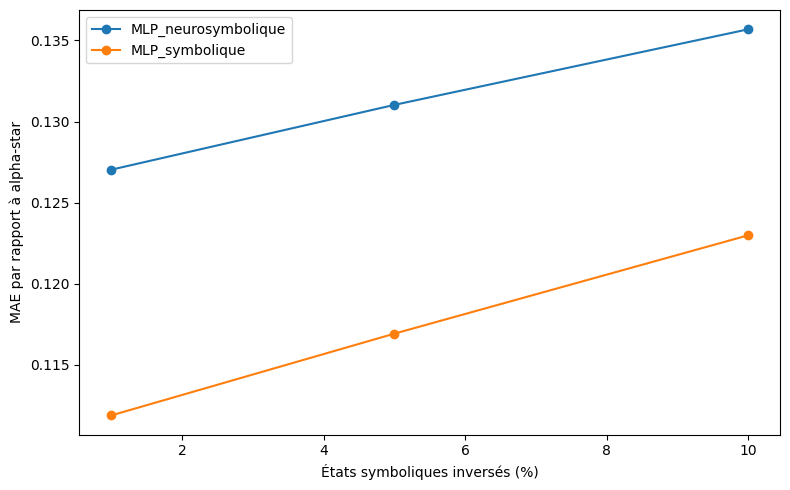

In [59]:
# Cellule 18 — Figure finale : robustesse symbolique


plt.figure(
    figsize=(8, 5)
)

for variant_name in sorted(
    robustness_symbolic_final[
        "variant"
    ].unique()
):
    subset = (
        robustness_symbolic_final[
            robustness_symbolic_final[
                "variant"
            ].eq(variant_name)
        ]
        .sort_values(
            "flip_rate"
        )
    )

    plt.plot(
        100.0
        * subset[
            "flip_rate"
        ],
        subset[
            "mae_mean"
        ],
        marker="o",
        label=variant_name,
    )

plt.xlabel(
    "États symboliques inversés (%)"
)

plt.ylabel(
    "MAE par rapport à alpha-star"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FINAL_FIGURES_DIR
    / "figure_finale_robustesse_symbolique.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

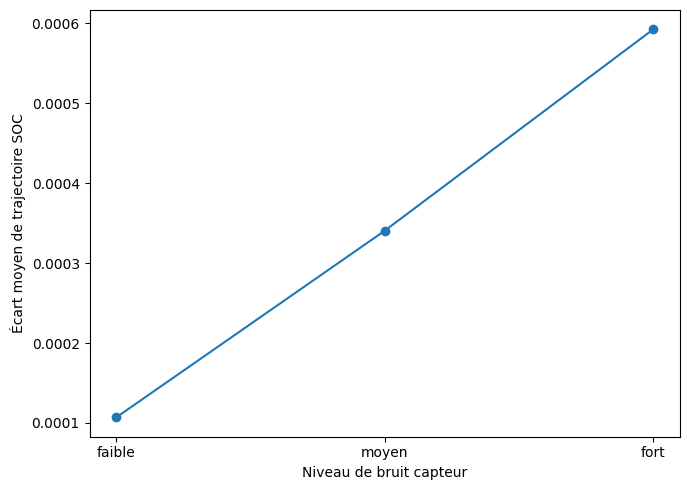

In [60]:
# Cellule 19 — Figure dynamique sous bruit

if robustness_dynamic is not None:
    dynamic_data = (
        robustness_dynamic.copy()
    )

    level_order = {
        "faible": 0,
        "moyen": 1,
        "fort": 2,
    }

    dynamic_data[
        "level_order"
    ] = dynamic_data[
        "level"
    ].map(
        level_order
    )

    dynamic_data = (
        dynamic_data
        .sort_values(
            "level_order"
        )
    )

    trajectory_column = next(
        (
            column
            for column in [
                "trajectory_soc_mae_mean",
                "ecart_trajectoire_soc_mae",
            ]
            if column in dynamic_data.columns
        ),
        None,
    )

    if trajectory_column is not None:
        plt.figure(
            figsize=(7, 5)
        )

        plt.plot(
            dynamic_data[
                "level"
            ],
            dynamic_data[
                trajectory_column
            ],
            marker="o",
        )

        plt.xlabel(
            "Niveau de bruit capteur"
        )

        plt.ylabel(
            "Écart moyen de trajectoire SOC"
        )

        plt.tight_layout()

        plt.savefig(
            FINAL_FIGURES_DIR
            / "figure_finale_robustesse_dynamique.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()
    else:
        print(
            "Aucune colonne d'écart de trajectoire "
            "trouvée dans le fichier dynamique."
        )
else:
    print(
        "Résultats dynamiques de robustesse absents."
    )


In [61]:
# Cellule 20 — Tableau synthétique des rôles


component_roles = pd.DataFrame([
    {
        "component": "Alpha-star",
        "role": (
            "Cible optimale hors ligne "
            "sous contraintes physiques"
        ),
        "status": "Professeur hors ligne",
    },
    {
        "component": "MLP physique",
        "role": (
            "Baseline neuronale de "
            "répartition de puissance"
        ),
        "status": "Baseline",
    },
    {
        "component": (
            "MLP physique + symbolique"
        ),
        "role": (
            "Décideur neurosymbolique "
            "principal"
        ),
        "status": "Modèle opérationnel",
    },
    {
        "component": "LSTM neurosymbolique",
        "role": (
            "Anticipation de la demande "
            "et de l'évolution des SOC"
        ),
        "status": "Module prédictif",
    },
    {
        "component": "Fuzzy-v1",
        "role": (
            "Stratégie explicable et "
            "solution de secours"
        ),
        "status": "Contrôleur de référence",
    },
    {
        "component": "Ontologie",
        "role": (
            "États symboliques, relations, "
            "règles et explications"
        ),
        "status": "Couche symbolique",
    },
    {
        "component": "Filtre de sécurité",
        "role": (
            "Projection physique, protection "
            "des batteries et bilan énergétique"
        ),
        "status": "Couche de sécurité",
    },
    {
        "component": "GNN simple",
        "role": (
            "Approximation de la stratégie "
            "historique EB-priority"
        ),
        "status": "Baseline structurelle",
    },
])

display(component_roles)

component_roles.to_csv(
    FINAL_TABLES_DIR
    / "tableau_final_role_composants.csv",
    index=False,
)

,component,role,status
0,Alpha-star,Cible optimale hors ligne sous contraintes phy...,Professeur hors ligne
1,MLP physique,Baseline neuronale de répartition de puissance,Baseline
2,MLP physique + symbolique,Décideur neurosymbolique principal,Modèle opérationnel
3,LSTM neurosymbolique,Anticipation de la demande et de l'évolution d...,Module prédictif
4,Fuzzy-v1,Stratégie explicable et solution de secours,Contrôleur de référence
5,Ontologie,"États symboliques, relations, règles et explic...",Couche symbolique
6,Filtre de sécurité,"Projection physique, protection des batteries ...",Couche de sécurité
7,GNN simple,Approximation de la stratégie historique EB-pr...,Baseline structurelle


In [62]:
# Cellule 21 — Synthèse automatique des résultats


best_regression_row = (
    regression_test.iloc[0]
)

best_test_physical_row = (
    physical_test[
        physical_test[
            "strategy"
        ].isin(
            ABLATION_MODEL_NAMES
        )
    ]
    .sort_values(
        "cost_mean"
    )
    .iloc[0]
)

summary_results = {
    "strict_validation_winner": (
        strict_validation_winner
    ),
    "strict_validation_cost": (
        strict_validation_cost
    ),
    "operational_neurosymbolic_model": (
        OPERATIONAL_NEUROSYMBOLIC_MODEL
    ),
    "operational_seed": (
        operational_seed
    ),
    "best_test_regression_model": str(
        best_regression_row[
            "strategy"
        ]
    ),
    "best_test_mae": float(
        best_regression_row[
            "mae_mean"
        ]
    ),
    "best_test_r2": float(
        best_regression_row[
            "r2_mean"
        ]
    ),
    "best_test_physical_model": str(
        best_test_physical_row[
            "strategy"
        ]
    ),
    "best_test_physical_cost": float(
        best_test_physical_row[
            "cost_mean"
        ]
    ),
    "operational_checkpoint": str(
        operational_checkpoint
    ),
    "operational_scaler": str(
        operational_scaler
    ),
}

summary_file = (
    FINAL_TABLES_DIR
    / "synthese_resultats_finaux.json"
)

with open(
    summary_file,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary_results,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(
    json.dumps(
        summary_results,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "strict_validation_winner": "MLP_LSTM",
  "strict_validation_cost": 0.2122228790180483,
  "operational_neurosymbolic_model": "MLP_symbolique",
  "operational_seed": 44,
  "best_test_regression_model": "MLP_symbolique",
  "best_test_mae": 0.1107160498698552,
  "best_test_r2": 0.5899864037831625,
  "best_test_physical_model": "MLP_symbolique",
  "best_test_physical_cost": 0.2171783760687923,
  "operational_checkpoint": "C:\\Users\\Admin\\Desktop\\Projet_Artemis2\\models\\ablation_MLP_symbolique_seed_44.pt",
  "operational_scaler": "C:\\Users\\Admin\\Desktop\\Projet_Artemis2\\models\\ablation_MLP_symbolique_scaler.npz"
}


In [63]:

# Cellule 22 — Manifeste des livrables finaux


final_manifest = {
    "tables_directory": str(
        FINAL_TABLES_DIR
    ),
    "figures_directory": str(
        FINAL_FIGURES_DIR
    ),
    "operational_model": (
        OPERATIONAL_NEUROSYMBOLIC_MODEL
    ),
    "operational_seed": (
        operational_seed
    ),
    "checkpoint": str(
        operational_checkpoint
    ),
    "scaler": str(
        operational_scaler
    ),
    "final_tables": sorted(
        path.name
        for path in FINAL_TABLES_DIR.glob(
            "*.csv"
        )
    ),
    "final_figures": sorted(
        path.name
        for path in FINAL_FIGURES_DIR.glob(
            "*.png"
        )
    ),
}

manifest_file = (
    FINAL_TABLES_DIR
    / "manifest_final.json"
)

with open(
    manifest_file,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_manifest,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(
    "Manifeste final :",
    manifest_file,
)

print()
print("Tables finales :")

for filename in final_manifest[
    "final_tables"
]:
    print(" -", filename)

print()
print("Figures finales :")

for filename in final_manifest[
    "final_figures"
]:
    print(" -", filename)

Manifeste final : C:\Users\Admin\Desktop\Projet_Artemis2\results\tables\final\manifest_final.json

Tables finales :
 - selection_architecture_finale.csv
 - tableau_final_contribution_composants.csv
 - tableau_final_physique_test.csv
 - tableau_final_physique_validation.csv
 - tableau_final_regression.csv
 - tableau_final_robustesse_lstm.csv
 - tableau_final_robustesse_symbolique.csv
 - tableau_final_role_composants.csv
 - tableau_final_simulation_dynamique.csv

Figures finales :
 - figure_finale_ablation_mae.png
 - figure_finale_cout_physique.png
 - figure_finale_robustesse_dynamique.png
 - figure_finale_robustesse_lstm.png
 - figure_finale_robustesse_symbolique.png
